In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
import keras_tuner as kt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

2025-12-11 15:16:06.763784: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Channel-Independent Detection 

## 1D-CNN with LSTM

1D-CNN with LSTM: 
- input 1600 signals
- output label (0/1)

Architecture:

Get X => normalize => Conv1D => BatchNorm => MaxPool1D => Conv1D => BatchNorm => Dropout => Maxpool...

In [2]:
from tensorflow.keras.layers import Input, Activation, BatchNormalization

In [3]:
import torch
import torch.nn as nn

class CNNWithLSTM(nn.Module):
    def __init__(self):
        super(CNNWithLSTM, self).__init__()

        # CNN layers
        self.conv1 = nn.Conv1d(1, 16, kernel_size=2)
        self.bn1   = nn.BatchNorm1d(16)

        self.conv2 = nn.Conv1d(16, 32, kernel_size=2)
        self.bn2   = nn.BatchNorm1d(32)
        self.dropout1 = nn.Dropout(0.2)
        self.pool1 = nn.MaxPool1d(kernel_size=3)

        self.conv3 = nn.Conv1d(32, 128, kernel_size=1)
        self.bn3   = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.2)
        self.pool2 = nn.MaxPool1d(kernel_size=3)

        self.conv4 = nn.Conv1d(128, 256, kernel_size=2)
        self.bn4   = nn.BatchNorm1d(256)
        self.dropout3 = nn.Dropout(0.3)
        self.pool3 = nn.MaxPool1d(kernel_size=3)

        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=256,
            batch_first=True
        )

        # Dense layers
        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 1)

        self.sigmoid = nn.Sigmoid()


    def forward(self, x):
        # x shape: (batch, 1600, 1) → convert to (batch, channels, length)
        x = x.permute(0, 2, 1)

        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.dropout1(self.pool1(x))

        x = torch.relu(self.bn3(self.conv3(x)))
        x = self.dropout2(self.pool2(x))

        x = torch.relu(self.bn4(self.conv4(x)))
        x = self.dropout3(self.pool3(x))

        # Prepare for LSTM: (batch, channels, seq_len) → (batch, seq_len, channels)
        x = x.permute(0, 2, 1)

        # LSTM
        _, (h, _) = self.lstm(x)   # h: (1, batch, 256)
        x = h[-1]                  # (batch, 256)

        # Dense layers
        x = torch.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))

        return x

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CNNWithLSTM().to(device)

print("Running on:", device)


Running on: cuda


In [5]:
dummy_input = torch.randn(8, 1600, 1).to(device)
out = model(dummy_input)

print(out.shape)   # torch.Size([8, 1])


torch.Size([8, 1])


## Data Processing

We have 101 blocks in every channel in every rat. Let 80 be for training, 11 for validating, 10 for testing

In [6]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader

root_dir = "data/brainrat_cmps364/Day3_Rats"

X_list = []
y_list = []

rats = ["R1", "R2", "R3"]
channels = ["Channel_1", "Channel_2", "Channel_3"]

for rat in rats:
    rat_path = os.path.join(root_dir, rat)
    for channel in channels:
        folder_name = f"{rat}_{channel}"         # e.g., R1_Channel_1
        folder_path = os.path.join(rat_path, folder_name)
        
        for file_name in os.listdir(folder_path):
            if file_name.endswith(".csv") and '102' not in file_name:
                file_path = os.path.join(folder_path, file_name)
                
                data = np.loadtxt(file_path, delimiter=",")
                X = data[:, :1600]
                y = data[:, 1600]

                X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)
                
                X_list.append(X)
                y_list.append(y)

# Combine all data
X_all = np.vstack(X_list)
y_all = np.hstack(y_list)

print("Total data points:", X_all.shape, y_all.shape)


Total data points: (544491, 1600) (544491,)


In [7]:
# Train/test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify = y_all, shuffle=True
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size = 0.5, random_state = 42, stratify = y_temp, shuffle = True
)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)  
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)

X_valid_tensor = torch.tensor(X_valid, dtype=torch.float32).unsqueeze(-1)  
y_valid_tensor = torch.tensor(y_valid, dtype=torch.float32).unsqueeze(-1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

# Datasets and loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Number of train batches:", len(train_loader))
print("Number of validation batches:", len(valid_loader))
print("Number of test batches:", len(test_loader))


Number of train batches: 6807
Number of validation batches: 851
Number of test batches: 851


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

In [9]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [10]:
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    
    for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Train"):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * X_batch.size(0)
    
    train_loss /= len(train_loader.dataset)
    
    # Validation
    model.eval()
    valid_loss = 0.0
    correct = 0
    
    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            valid_loss += loss.item() * X_batch.size(0)
            
            preds = (outputs >= 0.5).float()
            correct += (preds == y_batch).sum().item()
    
    valid_loss /= len(valid_loader.dataset)
    accuracy = correct / len(valid_loader.dataset)
    
    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Valid Loss={valid_loss:.4f}, Valid Acc={accuracy:.4f}")

Epoch 1/50 - Train: 100%|██████████| 6807/6807 [01:08<00:00, 98.71it/s] 


Epoch 1: Train Loss=0.0521, Valid Loss=0.0422, Valid Acc=0.9813


Epoch 2/50 - Train: 100%|██████████| 6807/6807 [01:08<00:00, 99.57it/s] 


Epoch 2: Train Loss=0.0451, Valid Loss=0.0424, Valid Acc=0.9814


Epoch 3/50 - Train: 100%|██████████| 6807/6807 [01:04<00:00, 105.21it/s]


...

Epoch 48: Train Loss=0.0231, Valid Loss=0.0306, Valid Acc=0.9871


Epoch 49/50 - Train: 100%|██████████| 6807/6807 [01:09<00:00, 98.04it/s] 


Epoch 49: Train Loss=0.0230, Valid Loss=0.0311, Valid Acc=0.9877


Epoch 50/50 - Train: 100%|██████████| 6807/6807 [01:08<00:00, 99.08it/s] 


Epoch 50: Train Loss=0.0226, Valid Loss=0.0308, Valid Acc=0.9871


In [116]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = (outputs >= 0.5).float().cpu()  # move to CPU
        y_pred.extend(preds.numpy())
        y_true.extend(y_batch.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")


Precision: 0.8640
Recall: 0.8815
F1 Score: 0.8727
Accuracy: 0.9876


In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = (outputs >= 0.5).float().cpu()  # move to CPU
        y_pred.extend(preds.numpy())
        y_true.extend(y_batch.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Precision: 0.8883
Recall: 0.9046
F1 Score: 0.8964


In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in valid_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = (outputs >= 0.5).float().cpu()  # move to CPU
        y_pred.extend(preds.numpy())
        y_true.extend(y_batch.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Precision: 0.8584
Recall: 0.8758
F1 Score: 0.8670


# Ecog Data Processing

In [63]:
base_dir = "data/brainrat_cmps364/Ecog"   # root folder

X = []
y = []

for ecog_folder in sorted(os.listdir(base_dir)):
    if 'Ecog' not in ecog_folder:
        continue
    ecog_path = os.path.join(base_dir, ecog_folder)

    if not os.path.isdir(ecog_path):
        continue

    # channel1, channel2, channel3
    for channel_folder in sorted(os.listdir(ecog_path)):
        channel_path = os.path.join(ecog_path, channel_folder)

        if not os.path.isdir(channel_path):
            continue

        # Read all CSV files in this channel
        for fname in sorted(os.listdir(channel_path)):
            if fname.endswith(".csv"):
                fpath = os.path.join(channel_path, fname)

                # Load CSV (assuming no header)
                data = pd.read_csv(fpath, header=None).values  # shape: (num_rows, 1601)

                # Split into X (first 1600) and y (last column)
                x_temp = data[:,:-1]

                x_temp = (x_temp - x_temp.mean(axis=0)) / (x_temp.std(axis=0) + 1e-8)

                X.append(x_temp)
                y.append(data[:, -1])

# Convert lists to arrays
X_ecog_all = np.vstack(X)   # shape: (total_rows, 1600)
y_ecog_all = np.hstack(y)   # shape: (total_rows,)

print("X shape:", X_ecog_all.shape)
print("y shape:", y_ecog_all.shape)

X shape: (28032, 1600)
y shape: (28032,)


In [64]:
mask = y_ecog_all != 1   # True for all samples where y != 1

X_ecog_all = X_ecog_all[mask]
y_ecog_all = y_ecog_all[mask]

In [46]:
y_ecog_all[y_ecog_all == 1] = 0

In [65]:
y_ecog_all[y_ecog_all == 2] = 1

In [66]:
# Train/test split
X_ecog_train, X_ecog_temp, y_ecog_train, y_ecog_temp = train_test_split(
    X_ecog_all, y_ecog_all, test_size=0.2, random_state=42, stratify = y_ecog_all, shuffle=True
)

X_ecog_valid, X_ecog_test, y_ecog_valid, y_ecog_test = train_test_split(
    X_ecog_temp, y_ecog_temp, test_size = 0.5, random_state = 42, stratify = y_ecog_temp, shuffle = True
)

# Convert to PyTorch tensors
X_ecog_train_tensor = torch.tensor(X_ecog_train, dtype=torch.float32).unsqueeze(-1)  
y_ecog_train_tensor = torch.tensor(y_ecog_train, dtype=torch.float32).unsqueeze(-1)

X_ecog_valid_tensor = torch.tensor(X_ecog_valid, dtype=torch.float32).unsqueeze(-1)  
y_ecog_valid_tensor = torch.tensor(y_ecog_valid, dtype=torch.float32).unsqueeze(-1)

X_ecog_test_tensor = torch.tensor(X_ecog_test, dtype=torch.float32).unsqueeze(-1)
y_ecog_test_tensor = torch.tensor(y_ecog_test, dtype=torch.float32).unsqueeze(-1)

# Datasets and loaders
train_ecog_dataset = TensorDataset(X_ecog_train_tensor, y_ecog_train_tensor)
valid_ecog_dataset = TensorDataset(X_ecog_valid_tensor, y_ecog_valid_tensor)
test_ecog_dataset = TensorDataset(X_ecog_test_tensor, y_ecog_test_tensor)

train_ecog_loader = DataLoader(train_ecog_dataset, batch_size=64, shuffle=True)
valid_ecog_loader = DataLoader(valid_ecog_dataset, batch_size=64, shuffle=False)
test_ecog_loader = DataLoader(test_ecog_dataset, batch_size=64, shuffle=False)

print("Number of train batches:", len(train_ecog_loader))
print("Number of validation batches:", len(valid_ecog_loader))
print("Number of test batches:", len(test_ecog_loader))


Number of train batches: 286
Number of validation batches: 36
Number of test batches: 36


## Using this model on Ecog

In [122]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_ecog = CNNWithLSTM().to(device)

print("Running on:", device)


Running on: cuda


In [123]:
criterion_ecog = nn.BCELoss()
optimizer_ecog = optim.Adam(model_ecog.parameters(), lr=0.001)

In [124]:
print("Unique labels:", np.unique(y_ecog_all))

Unique labels: [0. 1.]


In [125]:
((y_ecog_all) == 0).mean().item() * 100

69.15507740750459

In [126]:
y_test.shape

(54450,)

In [ ]:
#Label 0 = no seizure
#Label 1 = pre-ictal
#Label 2 = seizure

In [127]:
num_epochs = 50

for epoch in range(num_epochs):
    model_ecog.train()
    train_ecog_loss = 0.0
    
    for X_batch, y_batch in tqdm(train_ecog_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Train"):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer_ecog.zero_grad()
        outputs_ecog = model_ecog(X_batch)
        loss_ecog = criterion_ecog(outputs_ecog, y_batch)
        loss_ecog.backward()
        optimizer_ecog.step()
        
        train_ecog_loss += loss_ecog.item() * X_batch.size(0)
    
    train_ecog_loss /= len(train_ecog_loader.dataset)
    
    # Validation
    model_ecog.eval()
    valid_ecog_loss = 0.0
    correct_ecog = 0
    
    with torch.no_grad():
        for X_batch, y_batch in valid_ecog_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs_ecog = model_ecog(X_batch)
            loss_ecog = criterion_ecog(outputs_ecog, y_batch)
            valid_ecog_loss += loss_ecog.item() * X_batch.size(0)
            
            preds_ecog = (outputs_ecog >= 0.5).float()
            correct_ecog += (preds_ecog == y_batch).sum().item()
    
    valid_ecog_loss /= len(valid_ecog_loader.dataset)
    accuracy_ecog = correct_ecog / len(valid_ecog_loader.dataset)
    
    print(f"Epoch {epoch+1}: Train Loss={train_ecog_loss:.4f}, Valid Loss={valid_ecog_loss:.4f}, Valid Acc={accuracy_ecog:.4f}")

Epoch 1/50 - Train: 100%|██████████| 286/286 [00:01<00:00, 143.45it/s]


Epoch 1: Train Loss=0.3910, Valid Loss=0.4624, Valid Acc=0.8321


Epoch 2/50 - Train: 100%|██████████| 286/286 [00:01<00:00, 148.28it/s]


Epoch 2: Train Loss=0.2469, Valid Loss=0.3531, Valid Acc=0.8763


Epoch 3/50 - Train: 100%|██████████| 286/286 [00:01<00:00, 146.57it/s]


...

Epoch 48: Train Loss=0.0421, Valid Loss=0.3189, Valid Acc=0.9335


Epoch 49/50 - Train: 100%|██████████| 286/286 [00:01<00:00, 160.31it/s]


Epoch 49: Train Loss=0.0390, Valid Loss=0.2741, Valid Acc=0.9410


Epoch 50/50 - Train: 100%|██████████| 286/286 [00:01<00:00, 165.44it/s]


Epoch 50: Train Loss=0.0412, Valid Loss=0.2624, Valid Acc=0.9375


In [129]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

model_ecog.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in test_ecog_loader:
        X_batch = X_batch.to(device)
        outputs = model_ecog(X_batch)
        preds = (outputs >= 0.5).float().cpu()  # move to CPU
        y_pred.extend(preds.numpy())
        y_true.extend(y_batch.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")


Precision: 0.9179
Recall: 0.8711
F1 Score: 0.8939
Accuracy: 0.9362


# Finetuning on Ecog

In [138]:
finetune_model = CNNWithLSTM().to(device)
finetune_model.load_state_dict(model.state_dict())

<All keys matched successfully>

In [139]:
for layer in [finetune_model.conv1, finetune_model.bn1,
              finetune_model.conv2, finetune_model.bn2,]:
    for param in layer.parameters():
        param.requires_grad = False

In [140]:
criterion_fine = nn.BCELoss() 
optimizer_fine = optim.Adam(filter(lambda p: p.requires_grad, finetune_model.parameters()), lr=1e-6)

In [141]:
train_losses = []
valid_losses = []
valid_accuracies = []

num_epochs = 50

for epoch in range(num_epochs):
    finetune_model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_ecog_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer_fine.zero_grad()
        outputs = finetune_model(X_batch)
        loss = criterion_fine(outputs, y_batch)
        loss.backward()
        optimizer_fine.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_ecog_loader.dataset)

    finetune_model.eval()
    valid_loss = 0.0
    correct = 0

    with torch.no_grad():
        for X_batch, y_batch in valid_ecog_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = finetune_model(X_batch)
            loss = criterion_fine(outputs, y_batch)
            valid_loss += loss.item() * X_batch.size(0)

            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (preds == y_batch).sum().item()

    valid_loss /= len(valid_ecog_loader.dataset)
    valid_acc = correct / len(valid_ecog_loader.dataset)

    # store values for plots
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    valid_accuracies.append(valid_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | "
          f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")


Epoch 1/50 | Train Loss: 4.9595 | Valid Loss: 4.4477 | Valid Acc: 0.3083
Epoch 2/50 | Train Loss: 4.9037 | Valid Loss: 4.3729 | Valid Acc: 0.3083
Epoch 3/50 | Train Loss: 4.8373 | Valid Loss: 4.3372 | Valid Acc: 0.3083
Epoch 4/50 | Train Loss: 4.7469 | Valid Loss: 4.2434 | Valid Acc: 0.3083
Epoch 5/50 | Train Loss: 4.6561 | Valid Loss: 4.1737 | Valid Acc: 0.3083
Epoch 6/50 | Train Loss: 4.5826 | Valid Loss: 4.1627 | Valid Acc: 0.3083
Epoch 7/50 | Train Loss: 4.5063 | Valid Loss: 4.0529 | Valid Acc: 0.3083
Epoch 8/50 | Train Loss: 4.3985 | Valid Loss: 4.0218 | Valid Acc: 0.3083
Epoch 9/50 | Train Loss: 4.3462 | Valid Loss: 3.9547 | Valid Acc: 0.3083
Epoch 10/50 | Train Loss: 4.2748 | Valid Loss: 3.8345 | Valid Acc: 0.3083
Epoch 11/50 | Train Loss: 4.2047 | Valid Loss: 3.8130 | Valid Acc: 0.3083
Epoch 12/50 | Train Loss: 4.1504 | Valid Loss: 3.7833 | Valid Acc: 0.3083
Epoch 13/50 | Train Loss: 4.0552 | Valid Loss: 3.7202 | Valid Acc: 0.3083
Epoch 14/50 | Train Loss: 3.9986 | Valid Loss: 

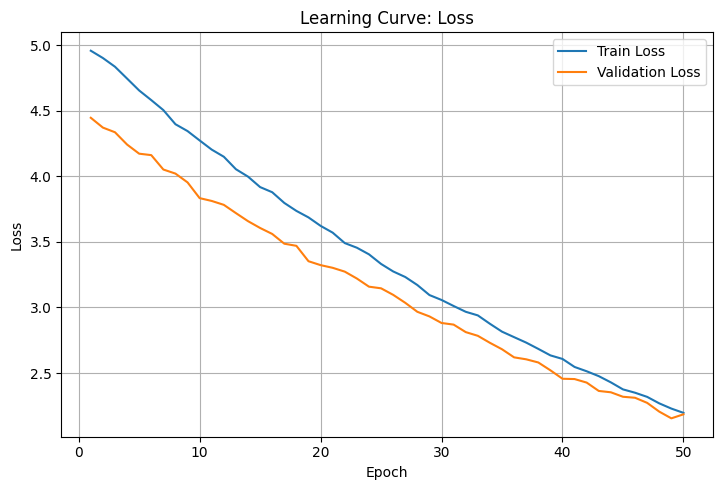

In [144]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(14,5))

# -------- Loss Curves --------
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, valid_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve: Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



In [143]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

finetune_model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in valid_ecog_loader:
        X_batch = X_batch.to(device)
        outputs = finetune_model(X_batch)
        preds = (outputs >= 0.5).float().cpu()  # move to CPU
        y_pred.extend(preds.numpy())
        y_true.extend(y_batch.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")


Precision: 0.4400
Recall: 0.0156
F1 Score: 0.0301
Accuracy: 0.6904


# Live Demonstration

In [99]:
import matplotlib.pyplot as plt
import torch

# Pick one seizure (y=1) and one non-seizure (y=0) sample
seizure_idx = np.where(y_all == 1)[0][0]  
nonseizure_idx = np.where(y_all == 0)[0][0]


# Get X samples
x_seizure = X_all[seizure_idx]
x_nonseizure = X_all[nonseizure_idx]

In [100]:
x_seizure.shape

(1600,)

In [106]:
x_seizure_tensor = torch.tensor(x_seizure, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
x_nonseizure_tensor = torch.tensor(x_nonseizure, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)

In [107]:
x_seizure_tensor.shape

torch.Size([1, 1600, 1])

In [110]:
t_seizure = np.arange(len(x_seizure)) / 1600
t_nonseizure = np.arange(len(x_nonseizure)) / 1600

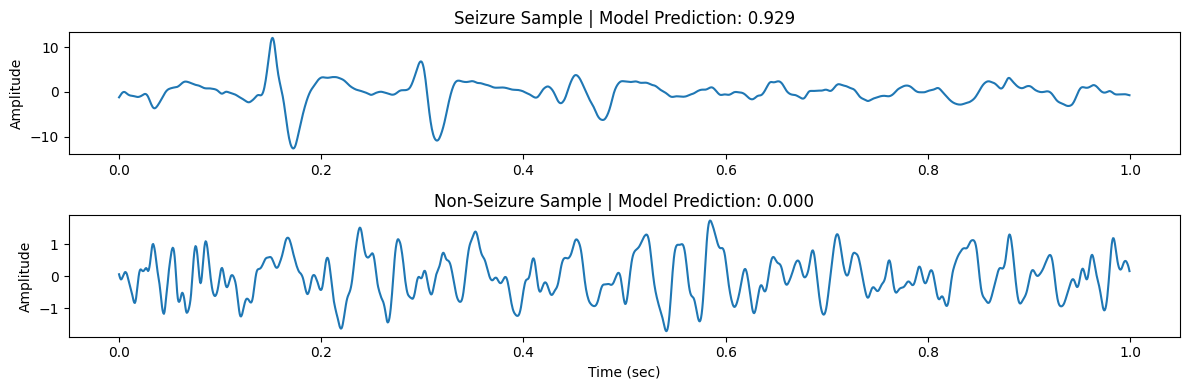

In [112]:
# Model predictions
model.eval()
with torch.no_grad():
    pred_seizure = model(x_seizure_tensor).item()
    pred_nonseizure = model(x_nonseizure_tensor).item()

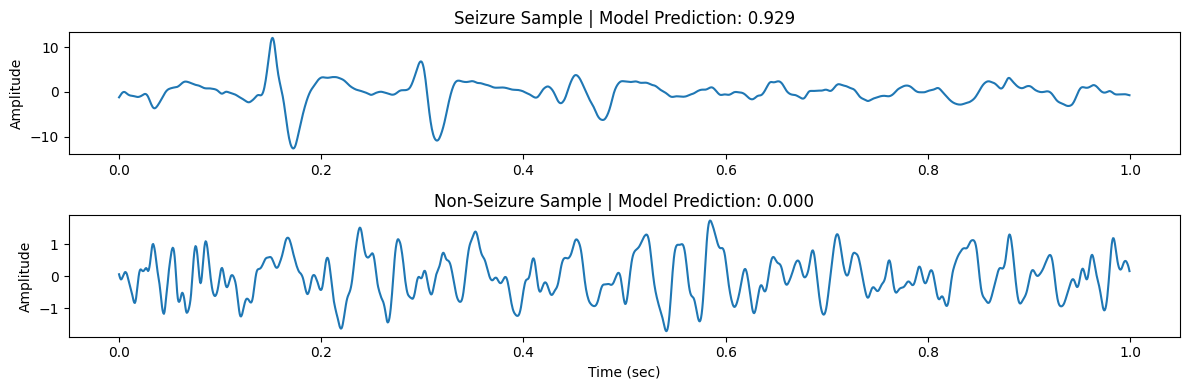

In [145]:
plt.figure(figsize=(12, 4))

plt.subplot(2, 1, 1)
plt.plot(t_seizure, x_seizure)
plt.title(f"Seizure Sample | Model Prediction: {pred_seizure:.3f}")
plt.ylabel("Amplitude")

plt.subplot(2, 1, 2)
plt.plot(t_nonseizure, x_nonseizure)
plt.title(f"Non-Seizure Sample | Model Prediction: {pred_nonseizure:.3f}")
plt.ylabel("Amplitude")
plt.xlabel("Time (sec)")

plt.tight_layout()
plt.show()

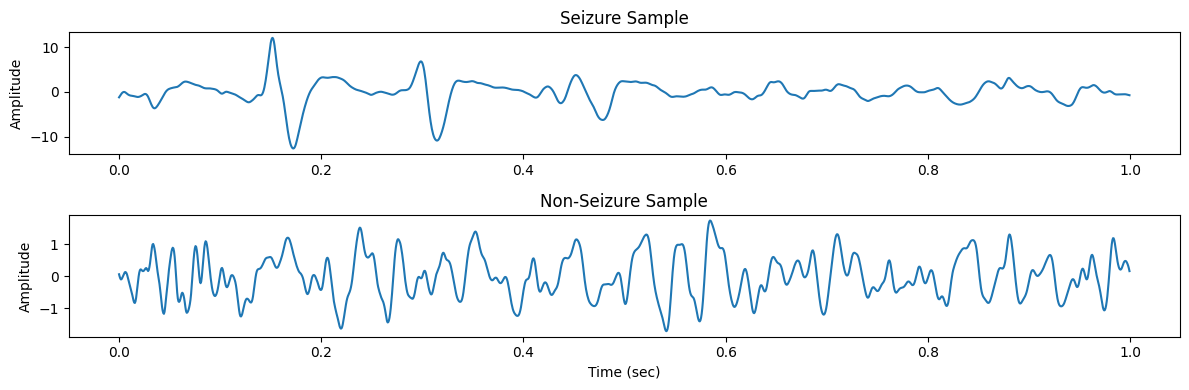

In [113]:
# Model predictions
model.eval()
with torch.no_grad():
    pred_seizure = model(x_seizure_tensor).item()
    pred_nonseizure = model(x_nonseizure_tensor).item()

# Plot
plt.figure(figsize=(12, 4))

plt.subplot(2, 1, 1)
plt.plot(t_seizure, x_seizure)
plt.title(f"Seizure Sample")
plt.ylabel("Amplitude")

plt.subplot(2, 1, 2)
plt.plot(t_nonseizure, x_nonseizure)
plt.title(f"Non-Seizure Sample")
plt.ylabel("Amplitude")
plt.xlabel("Time (sec)")

plt.tight_layout()
plt.show()
